# Análise exploratória — SOP (PCOS)

Inspeção inicial e EDA da base **PCOS Infertility** (biomarcadores).

- **Arquivo:** `src/db/models/polycystic-ovary-syndrome-pcos/PCOS_infertility.csv`
- **Alvo:** `PCOS (Y/N)` — 0 = sem SOP, 1 = com SOP
- **Figuras:** `src/db/outputs/polycystic-ovary-syndrome-pcos/01-analise-exploratoria/figures/`
- **Próximo:** notebook `02_preprocessamento.ipynb`


## 1 - Setup e carga dos dados


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def encontrar_raiz() -> Path:
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / "src" / "db").is_dir():
            return candidato
    raise FileNotFoundError("Raiz do repositório não encontrada.")

RAIZ = encontrar_raiz()
OUTPUT_BASE = RAIZ / "src/db/outputs/polycystic-ovary-syndrome-pcos"

CAMINHO_CSV = RAIZ / "src/db/models/polycystic-ovary-syndrome-pcos/PCOS_infertility.csv"
PASTA_BASE = OUTPUT_BASE / "01-analise-exploratoria"
PASTA_FIGURAS = PASTA_BASE / "figures"
PASTA_METRICAS = PASTA_BASE / "metrics"

for pasta in (PASTA_FIGURAS, PASTA_METRICAS):
    pasta.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
LIMITE_DETECCAO = 1.99


In [2]:
dados = pd.read_csv(CAMINHO_CSV)
dados.columns = dados.columns.str.strip()

MAPA_COLUNAS = {
    "I   beta-HCG(mIU/mL)": "beta_hcg_i",
    "II    beta-HCG(mIU/mL)": "beta_hcg_ii",
    "AMH(ng/mL)": "amh",
    "PCOS (Y/N)": "pcos",
    "Patient File No.": "patient_id",
    "Sl. No": "sl_no",
}
dados = dados.rename(columns=MAPA_COLUNAS)

for col in ("beta_hcg_i", "beta_hcg_ii", "amh"):
    dados[col] = pd.to_numeric(dados[col], errors="coerce")

print(f"Arquivo: {CAMINHO_CSV}")
print("Dimensão:", dados.shape)
dados.head()


Arquivo: E:\_git\fiap\fase1\tech-challenge-fase1\src\db\models\polycystic-ovary-syndrome-pcos\PCOS_infertility.csv
Dimensão: (541, 6)


,sl_no,patient_id,pcos,beta_hcg_i,beta_hcg_ii,amh
0,1,10001,0,1.99,1.99,2.07
1,2,10002,0,60.80,1.99,1.53
2,3,10003,1,494.08,494.08,6.63
3,4,10004,0,1.99,1.99,1.22
4,5,10005,0,801.45,801.45,2.26


## 2 - Qualidade dos dados


In [3]:
qualidade = {
    "linhas": len(dados),
    "colunas": len(dados.columns),
    "ausentes_por_coluna": dados.isna().sum().to_dict(),
    "duplicatas_linha_completa": int(dados.duplicated().sum()),
    "duplicatas_patient_id": int(dados["patient_id"].duplicated().sum()),
    "amh_invalidos": int(dados["amh"].isna().sum()),
    "beta_i_censurados_1_99": int((dados["beta_hcg_i"] == LIMITE_DETECCAO).sum()),
    "beta_ii_censurados_1_99": int((dados["beta_hcg_ii"] == LIMITE_DETECCAO).sum()),
}

perfil = dados.groupby(["beta_hcg_i", "beta_hcg_ii", "amh"], dropna=False)["pcos"].agg(["count", "nunique"])
conflitos = perfil[perfil["nunique"] > 1].reset_index()
qualidade["grupos_rotulo_conflitante"] = len(conflitos)

print(json.dumps(qualidade, indent=2, ensure_ascii=False))
if len(conflitos):
    print("\nExemplos de perfis com rótulo conflitante:")
    print(conflitos.head(10).to_string(index=False))


{
  "linhas": 541,
  "colunas": 6,
  "ausentes_por_coluna": {
    "sl_no": 0,
    "patient_id": 0,
    "pcos": 0,
    "beta_hcg_i": 0,
    "beta_hcg_ii": 0,
    "amh": 1
  },
  "duplicatas_linha_completa": 0,
  "duplicatas_patient_id": 0,
  "amh_invalidos": 1,
  "beta_i_censurados_1_99": 191,
  "beta_ii_censurados_1_99": 307,
  "grupos_rotulo_conflitante": 10
}

Exemplos de perfis com rótulo conflitante:
 beta_hcg_i  beta_hcg_ii   amh  count  nunique
       1.99         1.99  1.00      5        2
       1.99         1.99  1.03      2        2
       1.99         1.99  1.40      2        2
       1.99         1.99  2.80      3        2
       1.99         1.99  2.83      2        2
       1.99         1.99  6.00      3        2
       1.99         1.99  9.90      2        2
       1.99         1.99 16.90      2        2
       1.99         1.99 17.60      2        2
       2.00         3.01  9.10      2        2


## 3 - Distribuição do alvo e estatísticas por classe


C:\Users\ander\AppData\Local\Temp\ipykernel_18880\3012690701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x="pcos", ax=ax, palette="Set2")


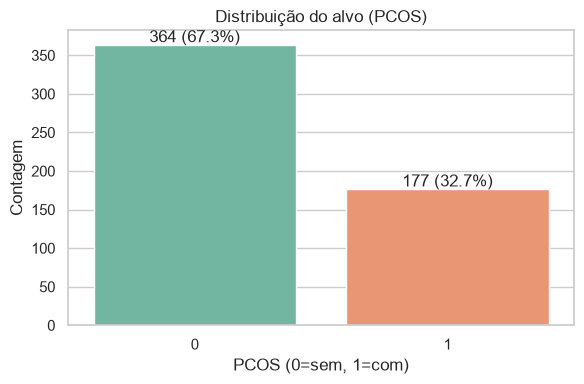

pcos                          0             1
beta_hcg_i  count    364.000000    177.000000
            mean     728.982437    532.042537
            std     3539.635651   2922.864267
            min        1.300000      1.920000
            25%        1.990000      1.990000
            50%       13.735000     70.530000
            75%      273.950000    346.590000
            max    32460.970000  30007.000000
beta_hcg_ii count    364.000000    177.000000
            mean     223.975137    267.543613
            std     1437.024331   1905.709760
            min        0.990000      0.110417
            25%        1.990000      1.990000
            50%        1.990000      1.990000
            75%       93.070000     99.690000
            max    21084.210000  25000.000000
amh         count    363.000000    177.000000
            mean       4.541496      7.844633
            std        4.290579      7.791138
            min        0.160000      0.100000
            25%        1.900000      2.600000
            50%        3.200000      5.900000
            75%        5.335000     10.200000
            max       26.800000     66.000000

In [4]:
contagem_alvo = dados["pcos"].value_counts().sort_index()
proporcao_alvo = dados["pcos"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=dados, x="pcos", ax=ax, palette="Set2")
ax.set_title("Distribuição do alvo (PCOS)")
ax.set_xlabel("PCOS (0=sem, 1=com)")
ax.set_ylabel("Contagem")
for i, v in enumerate(contagem_alvo.values):
    ax.text(i, v + 3, f"{v} ({proporcao_alvo.iloc[i]:.1%})", ha="center")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "distribuicao_alvo.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

resumo = dados.groupby("pcos")[["beta_hcg_i", "beta_hcg_ii", "amh"]].describe().T
resumo


## 4 - Biomarcadores e censura (valor 1.99)


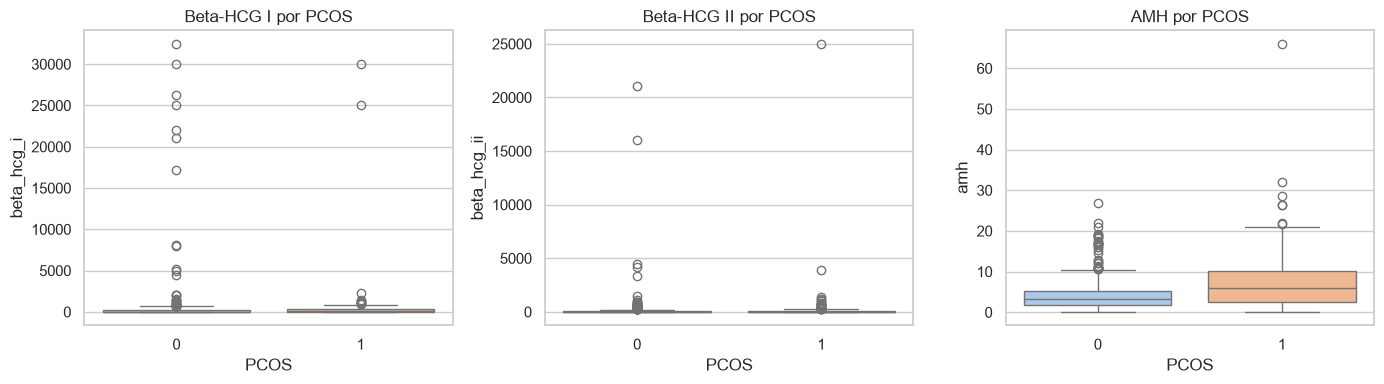

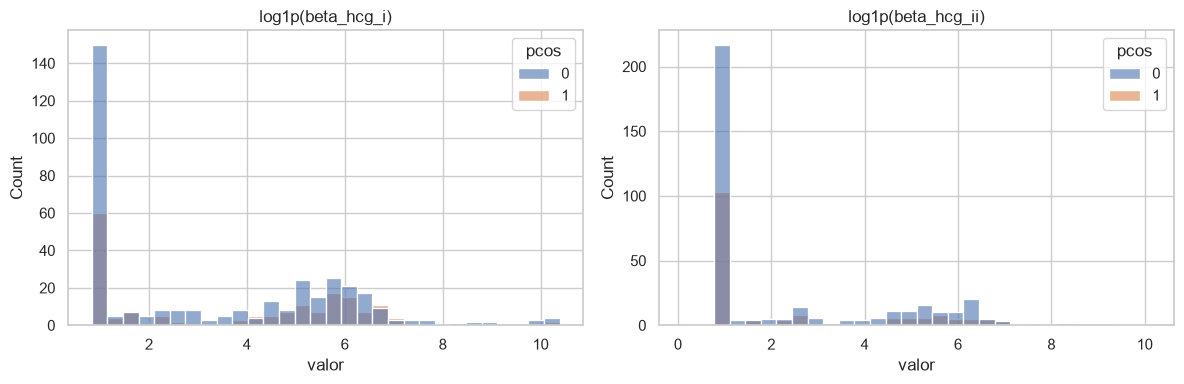

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, titulo in zip(
    axes,
    ["beta_hcg_i", "beta_hcg_ii", "amh"],
    ["Beta-HCG I", "Beta-HCG II", "AMH"],
):
    sns.boxplot(data=dados, x="pcos", y=col, hue="pcos", ax=ax, palette="pastel", legend=False)
    ax.set_title(f"{titulo} por PCOS")
    ax.set_xlabel("PCOS")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "boxplot_biomarcadores.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# Histogramas em escala log (beta-HCG)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["beta_hcg_i", "beta_hcg_ii"]):
    vals = dados[col].dropna()
    vals = vals[vals > 0]
    tmp = pd.DataFrame({
        "valor": np.log1p(vals),
        "pcos": dados.loc[vals.index, "pcos"].values,
    })
    sns.histplot(data=tmp, x="valor", hue="pcos", ax=ax, bins=30, alpha=0.6)
    ax.set_title(f"log1p({col})")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "hist_log_beta_hcg.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)


## 5 - Correlação e scatter


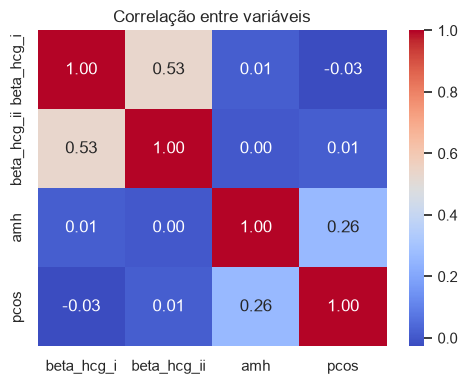

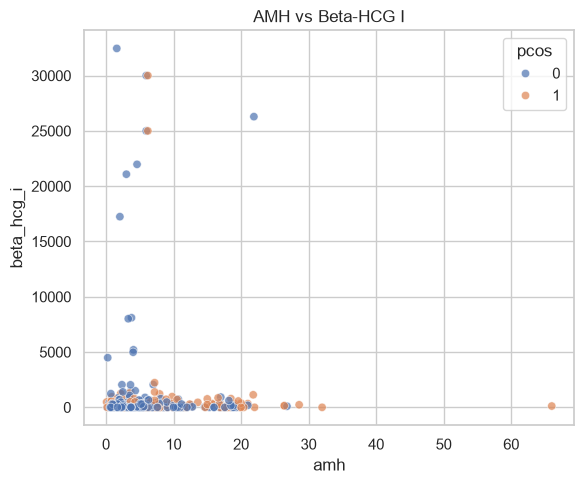

Métricas salvas: E:\_git\fiap\fase1\tech-challenge-fase1\src\db\outputs\polycystic-ovary-syndrome-pcos\01-analise-exploratoria\metrics\resumo_eda.json


In [6]:
cols_num = ["beta_hcg_i", "beta_hcg_ii", "amh", "pcos"]
matriz_corr = dados[cols_num].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlação entre variáveis")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "heatmap_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(
    data=dados,
    x="amh",
    y="beta_hcg_i",
    hue="pcos",
    alpha=0.7,
    ax=ax,
)
ax.set_title("AMH vs Beta-HCG I")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "scatter_amh_beta_i.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

with open(PASTA_METRICAS / "resumo_eda.json", "w", encoding="utf-8") as f:
    json.dump(qualidade, f, indent=2, ensure_ascii=False)
print("Métricas salvas:", PASTA_METRICAS / "resumo_eda.json")


## 6 - Síntese

- **AMH** tende a ser maior em pacientes com PCOS — principal candidato preditivo.
- Valores **1.99** em beta-HCG indicam limite de detecção; tratar no pré-processamento.
- Há **grupos com rótulo conflitante** para o mesmo perfil bioquímico — documentar como limitação.
- Este notebook não exporta artefato de modelagem.
